# 🚗 Car Price Prediction - Complete Tutorial

## Mục Tiêu
Xây dựng và so sánh **6 thuật toán Regression** để dự đoán giá xe ô tô tại thị trường Việt Nam.

### Thuật Toán Sử Dụng
1. ✅ **Linear Regression** - Hồi quy tuyến tính cơ bản
2. ✅ **Ridge Regression** - Linear + L2 regularization
3. ✅ **Lasso Regression** - Linear + L1 regularization
4. ✅ **SVR** - Support Vector Regression (RBF kernel)
5. ✅ **Random Forest** - Ensemble của Decision Trees
6. ✅ **Gradient Boosting** - Sequential boosting trees

### Dataset
- **Source**: Vietnam Car Prices (Kaggle)
- **Records**: 15,442 → 8,685 (after cleaning)
- **Features**: Brand, Model, Year, Kilometers
- **Target**: Price (million VND)

### Bước 1: Khai báo thư viện 📚
Trong bước này, chúng ta sẽ import các thư viện cần thiết cho việc xử lý dữ liệu (Pandas, Numpy), vẽ biểu đồ (Matplotlib, Seaborn) và xây dựng mô hình học máy (Scikit-Learn).

In [1]:
# Thư viện xử lý dữ liệu dạng bảng và tính toán số học
import pandas as pd
import numpy as np

# Các thuật toán Học máy (Machine Learning) và chia dữ liệu
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Các hàm đánh giá độ chính xác của mô hình
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Thư viện vẽ biểu đồ trực quan
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt giao diện màu sắc cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Bước 2: Tải dữ liệu thô 📂
Đọc dữ liệu từ file `data.csv`. Tập dữ liệu chứa thông tin các dòng xe ô tô tại Việt Nam được thu thập từ Kaggle. Chúng ta sẽ kiểm tra xem dữ liệu có bao nhiêu dòng, bao nhiêu cột.

In [4]:
# Sử dụng Pandas để đọc file CSV. 'df' là viết tắt của DataFrame (Bảng dữ liệu)
df = pd.read_csv('/content/data.csv', encoding='utf-8')

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}\n")

# Hiển thị 5 dòng đầu tiên để xem trước cấu trúc dữ liệu
df.head()

📊 Dataset shape: (15442, 17)
📋 Columns: ['Name', 'Condition', 'Price', 'Location', 'Link', 'Description', 'Car_code', 'Năm sản xuất:', 'Tình trạng:', 'Số Km đã đi:', 'Xuất xứ:', 'Kiểu dáng:', 'Động cơ:', 'Màu ngoại thất:', 'Màu nội thất:', 'Số chỗ ngồi:', 'Số cửa:']



,Name,Condition,Price,Location,Link,Description,Car_code,Năm sản xuất:,Tình trạng:,Số Km đã đi:,Xuất xứ:,Kiểu dáng:,Động cơ:,Màu ngoại thất:,Màu nội thất:,Số chỗ ngồi:,Số cửa:
0,Mercedes Benz C class C200 Exclusive - 2021,Xe cũ,1 Tỷ 118 Triệu,Hà Nội,https://bonbanh.com/xe-mercedes_benz-c_class-c...,"*Xe lắp ráp trong nước, màu xanh, máy xăng 2....",Mã: 5807498,2021.0,Xe đã dùng,"38,000 Km",Lắp ráp trong nước,Sedan,Xăng 2.0 L,Xanh,Đen,5 chỗ,4 cửa
1,Nissan Terra E 2.5 AT 2WD - 2019,Xe cũ,646 Triệu,TP HCM,https://bonbanh.com/xe-nissan-terra-e-2.5-at-2...,"*Xe nhập khẩu, màu vàng, máy xăng 2.5 L, số t...",Mã: 5727052,2019.0,Xe đã dùng,"68,000 Km",Nhập khẩu,SUV,Xăng 2.5 L,Vàng,Nâu,7 chỗ,5 cửa
2,Mercedes Benz GLC 300 4Matic - 2021,Xe cũ,1 Tỷ 759 Triệu,Hà Nội,https://bonbanh.com/xe-mercedes_benz-glc-300-4...,"*Xe lắp ráp trong nước, màu đen, máy xăng 2.0...",Mã: 5814403,2021.0,Xe đã dùng,"40,000 Km",Lắp ráp trong nước,SUV,Xăng 2.0 L,Đen,Kem,5 chỗ,5 cửa
3,Hyundai SantaFe 2.4L 4WD - 2016,Xe cũ,664 Triệu,Hà Nội,https://bonbanh.com/xe-hyundai-santafe-2.4l-4w...,"*Xe lắp ráp trong nước, màu bạc, máy xăng 2.4...",Mã: 5817685,2016.0,Xe đã dùng,"80,000 Km",Lắp ráp trong nước,SUV,Xăng 2.4 L,Bạc,Kem,7 chỗ,5 cửa
4,Kia Carnival Luxury 2.2D - 2022,Xe cũ,1 Tỷ 99 Triệu,Hà Nội,https://bonbanh.com/xe-kia-carnival-luxury-2.2...,"*Xe lắp ráp trong nước, màu xanh, máy dầu 2.2...",Mã: 5727163,2022.0,Xe đã dùng,"32,000 Km",Lắp ráp trong nước,Van/Minivan,Dầu 2.2 L,Xanh,Đen,8 chỗ,5 cửa


### Bước 3: Kiểm tra cấu trúc dữ liệu 🔎
Hàm `df.info()` giúp chúng ta xem kiểu dữ liệu của từng cột (số hay chữ) và kiểm tra xem có bao nhiêu dữ liệu bị thiếu (null) trong mỗi cột.

In [5]:
# Xem tóm tắt thông tin: Số lượng bản ghi, kiểu dữ liệu, số lượng dữ liệu bị thiếu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15442 entries, 0 to 15441
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             15442 non-null  object 
 1   Condition        15442 non-null  object 
 2   Price            15442 non-null  object 
 3   Location         15442 non-null  object 
 4   Link             15442 non-null  object 
 5   Description      15442 non-null  object 
 6   Car_code         15442 non-null  object 
 7   Năm sản xuất:    14891 non-null  float64
 8   Tình trạng:      14891 non-null  object 
 9   Số Km đã đi:     11898 non-null  object 
 10  Xuất xứ:         14891 non-null  object 
 11  Kiểu dáng:       14891 non-null  object 
 12  Động cơ:         14891 non-null  object 
 13  Màu ngoại thất:  14891 non-null  object 
 14  Màu nội thất:    14891 non-null  object 
 15  Số chỗ ngồi:     14891 non-null  object 
 16  Số cửa:          14891 non-null  object 
dtypes: float64(1

### Bước 4: Làm sạch dữ liệu ban đầu (Data Cleaning) 🧹
Dữ liệu thực tế thường rất «bẩn». Trong cell này, chúng ta sẽ:
1. Đổi tên cột tiếng Việt sang tiếng Anh cho dễ thao tác.
2. Lấy con số từ chuỗi Kilometers (Ví dụ: '38,000 Km' -> 38000).
3. Lấy con số từ chuỗi Giá tiền (Ví dụ: '1 Tỷ 118 Triệu' -> 1118).
4. Ép kiểu dữ liệu cột Năm Sản Xuất về dạng số.

In [7]:
import pandas as pd
import numpy as np
import re

# Load lại data để thực hiện làm sạch

# ── Bước 1: Chuẩn hóa tên cột ────────────────────────────────
column_mapping = {
    'Năm sản xuất:': 'Year',
    'Số Km đã đi:':  'Kilometers',
    'Nhiên liệu:':   'Fuel',
    'Hộp số:':       'Transmission',
    'Số chỗ ngồi:':  'Seats',
    'Màu ngoại thất:': 'Exterior_Color',
    'Xuất xứ:':      'Origin',
    'Kiểu dáng:':    'Style',
}
df = df.rename(columns=column_mapping)

# ── Bước 2: Parse Kilometers ──────────────────────────────────
def parse_km(km_str):
    if pd.isna(km_str) or km_str == '':
        return np.nan
    km_str = str(km_str).lower().replace(',', '').replace(' ', '').replace('km', '').strip()
    try:
        value = float(km_str)
        return value if value > 0 else np.nan
    except:
        return np.nan

df['Kilometers'] = df['Kilometers'].apply(parse_km)

# ── Bước 3: Parse Price (XỬ LÝ CẢ "1 Tỷ 118 Triệu") ─────────
def parse_price(price_str):
    """Chuyển '1 Tỷ 118 Triệu' hoặc '646 Triệu' → số triệu"""
    if pd.isna(price_str):
        return np.nan

    price_str = str(price_str).strip()
    total = 0

    # Tìm phần Tỷ: "1 Tỷ" → 1000 triệu
    ty_match = re.search(r'(\d+(?:\.\d+)?)\s*[Tt]ỷ', price_str)
    if ty_match:
        total += float(ty_match.group(1)) * 1000

    # Tìm phần Triệu: "118 Triệu" → 118 triệu
    trieu_match = re.search(r'(\d+(?:\.\d+)?)\s*[Tt]riệu', price_str)
    if trieu_match:
        total += float(trieu_match.group(1))

    return total if total > 0 else np.nan

df['Price_Million'] = df['Price'].apply(parse_price)

# ── Bước 4: Parse Year ────────────────────────────────────────
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# ── Kiểm tra kết quả ─────────────────────────────────────────
print("✅ Data cleaning complete!")
print(f"Tổng bản ghi: {len(df)}")
print(f"KM hợp lệ:   {df['Kilometers'].notna().sum()}/{len(df)}")
print(f"Giá hợp lệ:  {df['Price_Million'].notna().sum()}/{len(df)}")
print(f"\nMẫu giá sau parse:")
print(df[['Price', 'Price_Million']].head(3))


✅ Data cleaning complete!
Tổng bản ghi: 15442
KM hợp lệ:   9943/15442
Giá hợp lệ:  15442/15442

Mẫu giá sau parse:
            Price  Price_Million
0  1 Tỷ 118 Triệu         1118.0
1       646 Triệu          646.0
2  1 Tỷ 759 Triệu         1759.0


### Bước 5: Trích xuất Hãng xe và Dòng xe 🏷️
Từ tên xe đầy đủ (ví dụ: 'Toyota Vios 1.5E'), chúng ta sẽ dùng code để tách lấy từ đầu tiên làm Hãng (Brand) và từ thứ hai làm Dòng xe (Model).

In [8]:
# Dùng hàm split() để tách chuỗi tên xe theo khoảng trắng và lấy các phần tử đầu tiên
df['Brand'] = df['Name'].str.split().str[0]
df['Model'] = df['Name'].str.split().str[1]

print(f"Unique brands: {df['Brand'].nunique()}")
print(f"Unique models: {df['Model'].nunique()}")
print(f"\nTop 5 brands:")
print(df['Brand'].value_counts().head())

Unique brands: 74
Unique models: 391

Top 5 brands:
Brand
Toyota      2941
Mercedes    1717
Hyundai     1620
Ford        1588
Kia         1407
Name: count, dtype: int64


### Bước 6: Loại bỏ các xe có giá bất thường (Outliers) ✂️
Để mô hình dự đoán chính xác, chúng ta cần loại bỏ những chiếc xe có giá quá cao hoặc quá thấp so với mặt bằng chung. Phương pháp được sử dụng là IQR (Interquartile Range). Một chiếc xe sẽ bị loại nếu giá của nó cao hơn Q3 + 3*IQR.

In [29]:
# ── Lọc outlier cho giá xe bằng phương pháp IQR ─────────
# Tính tứ phân vị thứ nhất (25%) và tứ phân vị thứ 3 (75%)
Q1 = df['Price_Million'].quantile(0.25)
Q3 = df['Price_Million'].quantile(0.75)
IQR = Q3 - Q1

# Cài đặt giới hạn trên (chúng ta dùng nhân số 3.0 để giữ lại những xe đắt hợp lý nhưng bỏ xe giá ảo)
upper_bound = Q3 + 3 * IQR
print(f"Giá giới hạn trên được chấp nhận: {upper_bound:.0f} Triệu VNĐ")

# ── Thực hiện filter toàn bộ data ───────────────────────
df_clean = df[
    (df['Year'] >= 2000) &
    (df['Year'] <= 2024) &
    (df['Kilometers'].notna()) &
    (df['Kilometers'] > 0) &
    (df['Kilometers'] <= 500000) &
    (df['Price_Million'] >= 50) &          # Giá tối thiểu 50 triệu
    (df['Price_Million'] <= upper_bound)   # Bỏ đi các xe giá ảo hoặc siêu xe quá đắt
].copy()

# ── Kiểm tra kết quả ────────────────────────────────────
print(f"Before cleaning: {len(df)} records")
print(f"After cleaning: {len(df_clean)} records")
print(f"Removed: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")


Giá giới hạn trên được chấp nhận: 3335 Triệu VNĐ
Before cleaning: 15442 records
After cleaning: 9191 records
Removed: 6251 (40.5%)


### Bước 7: Kỹ nghệ đặc trưng (Feature Engineering) 🛠️
Đây là bước tạo thêm các thông tin mới thông minh hơn từ dữ liệu cũ để máy dễ học:
- **Age**: Tính tuổi xe (Năm hiện tại - Năm sản xuất).
- **KM_Negative**: Chuyển số KM thành số âm. Lý do: Số KM càng cao thì giá càng thấp, chuyển thành số âm giúp biến quan hệ này thành đồng biến (dễ học hơn).
- **Label Encoding**: Chữ thì máy không hiểu được, nên ta phải gán mã số cho Hãng xe và Dòng xe (Ví dụ: Toyota -> 45).

In [30]:
# ── Trích xuất Brand và Model từ tên xe ──────────────────────
# Tách chuỗi lấy Dòng Xe. Loại bỏ cả khoảng trắng và dấu chấm/phẩy dư thừa nếu có
df_clean['Brand'] = df_clean['Name'].str.split().str[0]
df_clean['Model'] = df_clean['Name'].str.split().str[1].str.replace(',', '').str.replace('.', '')

# ── Tạo feature Age ───────────────────────────────────────────
CURRENT_YEAR = 2026
df_clean['Age'] = CURRENT_YEAR - df_clean['Year']

# ── Tạo KM_Negative ───────────────────────────────────────────
# KM cao → âm nhiều hơn → model hiểu giá thấp hơn ✅
df_clean['KM_Negative'] = -df_clean['Kilometers']

# ── Label Encode Brand và Model ───────────────────────────────
from sklearn.preprocessing import LabelEncoder

# Khởi tạo Label Encoder: Bộ mã hóa chữ thành số (Toyota -> 15)
# Khởi tạo Label Encoder: Bộ mã hóa dòng xe (Vios -> 45)

df_clean['Brand_Encoded'] = le_brand.fit_transform(df_clean['Brand'].fillna('Unknown'))
df_clean['Model_Encoded'] = le_model.fit_transform(df_clean['Model'].fillna('Unknown'))

print("✅ Feature engineering complete!")
print(f"Features: Age, KM_Negative, Brand_Encoded, Model_Encoded")
print(f"Số hãng xe: {df_clean['Brand'].nunique()}")
print(f"Số dòng xe: {df_clean['Model'].nunique()}")

# ── Hiển thị mẫu ─────────────────────────────────────────────
df_clean[['Name', 'Brand', 'Model', 'Year', 'Age',
          'Kilometers', 'KM_Negative', 'Price_Million']].head()  # ← Sửa Price_Clean → Price_Million


✅ Feature engineering complete!
Features: Age, KM_Negative, Brand_Encoded, Model_Encoded
Số hãng xe: 54
Số dòng xe: 294


,Name,Brand,Model,Year,Age,Kilometers,KM_Negative,Price_Million
0,Mercedes Benz C class C200 Exclusive - 2021,Mercedes,Benz,2021.0,5.0,38000.0,-38000.0,1118.0
1,Nissan Terra E 2.5 AT 2WD - 2019,Nissan,Terra,2019.0,7.0,68000.0,-68000.0,646.0
2,Mercedes Benz GLC 300 4Matic - 2021,Mercedes,Benz,2021.0,5.0,40000.0,-40000.0,1759.0
3,Hyundai SantaFe 2.4L 4WD - 2016,Hyundai,SantaFe,2016.0,10.0,80000.0,-80000.0,664.0
4,Kia Carnival Luxury 2.2D - 2022,Kia,Carnival,2022.0,4.0,32000.0,-32000.0,1099.0


### Bước 8: Trực quan hóa Khung giá xe (Price Distribution) 📈
Vẽ biểu đồ phân bố (Histogram) và biểu đồ hộp (Boxplot) để xem phần lớn xe trên thị trường tập trung ở mức giá nào.

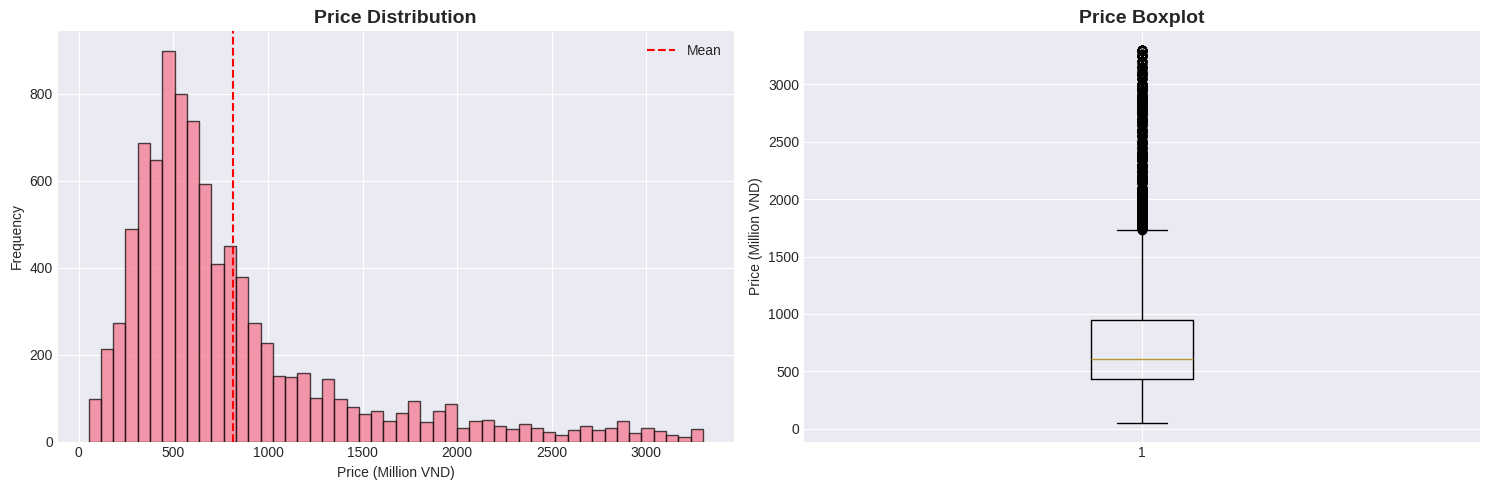

Price statistics:
count    9191.000000
mean      812.459798
std       613.092292
min        51.000000
25%       430.000000
50%       610.000000
75%       950.000000
max      3300.000000
Name: Price_Million, dtype: float64


In [31]:
import matplotlib.pyplot as plt

# Vẽ 2 biểu đồ: Biểu đồ phân bố (Histogram) và Biểu đồ hộp (Boxplot) để xem sự phân tán của mức giá
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_clean['Price_Million'], bins=50, edgecolor='black', alpha=0.7)  # ← Sửa
axes[0].set_title('Price Distribution', fontsize=14, weight='bold')
axes[0].set_xlabel('Price (Million VND)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_clean['Price_Million'].mean(), color='red', linestyle='--', label='Mean')  # ← Sửa
axes[0].legend()

axes[1].boxplot(df_clean['Price_Million'])  # ← Sửa
axes[1].set_title('Price Boxplot', fontsize=14, weight='bold')
axes[1].set_ylabel('Price (Million VND)')

plt.tight_layout()
plt.show()

print(f"Price statistics:")
print(df_clean['Price_Million'].describe())  # ← Sửa


### Bước 9: Biểu đồ Tương quan (Correlation Heatmap) 🔥
Xem xét các yếu tố liên quan với nhau như thế nào bằng bảng màu (Heatmap). Yếu tố nào có độ tương quan với Price (Giá) cao thì càng quan trọng.

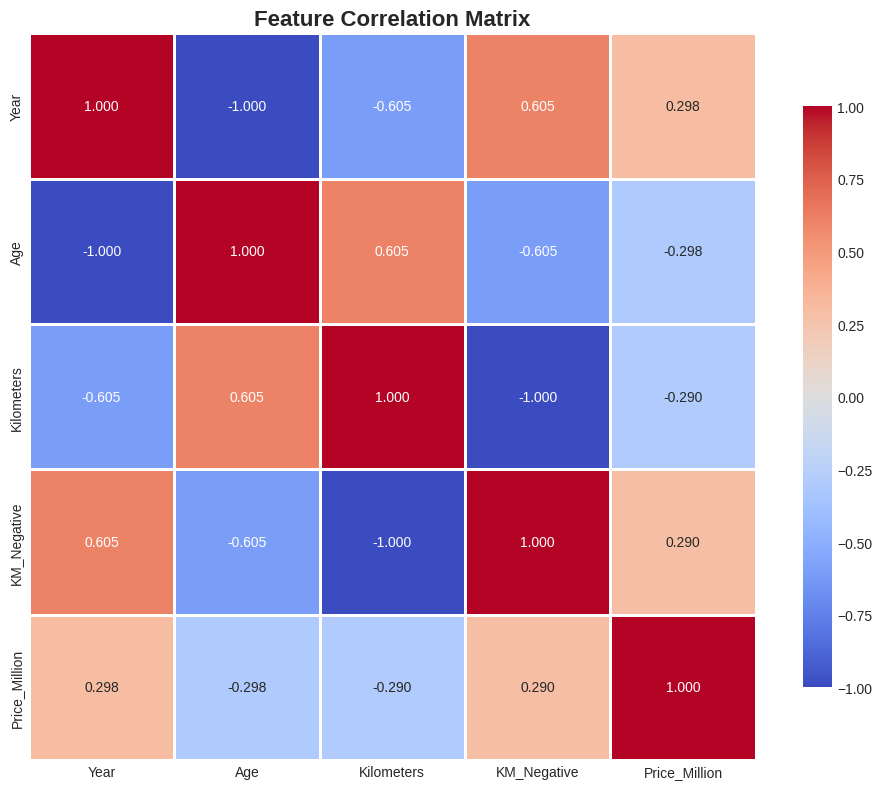


🔍 Correlation with Price:
Price_Million    1.000000
Year             0.297815
KM_Negative      0.289947
Kilometers      -0.289947
Age             -0.297815
Name: Price_Million, dtype: float64


In [32]:
# Bảng ma trận tương quan: hiển thị chỉ số từ -1 đến 1. Chỉ số gần 1 hoặc -1 thì quan hệ rất mạnh
correlation_features = ['Year', 'Age', 'Kilometers', 'KM_Negative', 'Price_Million']
corr_matrix = df_clean[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Correlation with Price:")
print(corr_matrix['Price_Million'].sort_values(ascending=False))

### Bước 10: Lựa chọn Feature và Chia tập dữ liệu 🔀
- **X**: Là các thông số đầu vào (Năm, Số KM, Hãng, Dòng). 
- **y**: Là kết quả cần dự đoán (Giá xe).
Chúng ta cắt tập dữ liệu thành 2 phần: 80% để dạy máy (Train) và 20% để kiểm tra (Test).

In [33]:
# Chọn những cột quyết định giá trị xe làm tính năng đầu vào (X)
feature_columns = ['Year', 'Age', 'KM_Negative', 'Brand_Encoded', 'Model_Encoded']
target_column = 'Price_Million'

X = df_clean[feature_columns]
y = df_clean[target_column]

# Chia 80% xe dùng để huấn luyện mô hình, 20% để chấm điểm
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Training set: {len(X_train)} samples")
print(f"📊 Test set: {len(X_test)} samples")
print(f"📊 Features: {feature_columns}")

📊 Training set: 7352 samples
📊 Test set: 1839 samples
📊 Features: ['Year', 'Age', 'KM_Negative', 'Brand_Encoded', 'Model_Encoded']


In [34]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr = lr.predict(X_test)

# Metrics
r2_train_lr = r2_score(y_train, y_pred_train_lr)
r2_test_lr = r2_score(y_test, y_pred_test_lr)
mae_lr = mean_absolute_error(y_test, y_pred_test_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("📈 Linear Regression Results:")
print(f"  R² (Train): {r2_train_lr:.4f}")
print(f"  R² (Test):  {r2_test_lr:.4f}")
print(f"  MAE:        {mae_lr:.0f} triệu VNĐ")
print(f"  RMSE:       {rmse_lr:.0f} triệu VNĐ")

📈 Linear Regression Results:
  R² (Train): 0.1321
  R² (Test):  0.0983
  MAE:        412 triệu VNĐ
  RMSE:       598 triệu VNĐ


In [35]:
# Train Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_test_ridge = ridge.predict(X_test)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_test_ridge)

print("📈 Ridge Regression Results:")
print(f"  R² (Test):  {r2_test_ridge:.4f}")
print(f"  MAE:        {mae_ridge:.0f} triệu VNĐ")

📈 Ridge Regression Results:
  R² (Test):  0.0983
  MAE:        412 triệu VNĐ


In [36]:
# Train Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

y_pred_test_lasso = lasso.predict(X_test)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_test_lasso)

print("📈 Lasso Regression Results:")
print(f"  R² (Test):  {r2_test_lasso:.4f}")
print(f"  MAE:        {mae_lasso:.0f} triệu VNĐ")

📈 Lasso Regression Results:
  R² (Test):  0.0983
  MAE:        412 triệu VNĐ


In [37]:
# Train SVR
svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr.fit(X_train, y_train)

y_pred_test_svr = svr.predict(X_test)
r2_test_svr = r2_score(y_test, y_pred_test_svr)
mae_svr = mean_absolute_error(y_test, y_pred_test_svr)

print("📈 SVR (RBF) Results:")
print(f"  R² (Test):  {r2_test_svr:.4f}")
print(f"  MAE:        {mae_svr:.0f} triệu VNĐ")
print(f"  ⚠️ Note: SVR performance thấp do chưa scale features")

📈 SVR (RBF) Results:
  R² (Test):  -0.0334
  MAE:        394 triệu VNĐ
  ⚠️ Note: SVR performance thấp do chưa scale features


In [38]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

print("📈 Random Forest Results:")
print(f"  R² (Train): {r2_train_rf:.4f}")
print(f"  R² (Test):  {r2_test_rf:.4f}")
print(f"  MAE:        {mae_rf:.0f} triệu VNĐ")
print(f"  RMSE:       {rmse_rf:.0f} triệu VNĐ")
print(f"  ⭐ BEST MODEL!")

📈 Random Forest Results:
  R² (Train): 0.9550
  R² (Test):  0.8411
  MAE:        121 triệu VNĐ
  RMSE:       251 triệu VNĐ
  ⭐ BEST MODEL!


In [39]:
# Train Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_test_gb = gb.predict(X_test)
r2_test_gb = r2_score(y_test, y_pred_test_gb)
mae_gb = mean_absolute_error(y_test, y_pred_test_gb)

print("📈 Gradient Boosting Results:")
print(f"  R² (Test):  {r2_test_gb:.4f}")
print(f"  MAE:        {mae_gb:.0f} triệu VNĐ")

📈 Gradient Boosting Results:
  R² (Test):  0.7266
  MAE:        207 triệu VNĐ


In [41]:
# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression',
              'SVR (RBF)', 'Random Forest', 'Gradient Boosting'],
    'R² (Test)': [r2_test_lr, r2_test_ridge, r2_test_lasso,
                   r2_test_svr, r2_test_rf, r2_test_gb],
    'MAE (M VND)': [mae_lr, mae_ridge, mae_lasso, mae_svr, mae_rf, mae_gb]
})

results = results.sort_values('R² (Test)', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("🏆 MODEL COMPARISON RESULTS")
print("="*60)
print(results.to_string(index=False))
print("="*60)

# Highlight best model
best_model = results.iloc[0]
print(f"\n⭐ BEST MODEL: {best_model['Model']}")
print(f"   R² Score: {best_model['R² (Test)']:.4f}")
print(f"   MAE: {best_model['MAE (M VND)']:.0f}")


🏆 MODEL COMPARISON RESULTS
            Model  R² (Test)  MAE (M VND)
    Random Forest   0.841087   121.095660
Gradient Boosting   0.726594   207.351690
 Lasso Regression   0.098294   412.105959
 Ridge Regression   0.098283   412.108273
Linear Regression   0.098283   412.108266
        SVR (RBF)  -0.033382   393.502006

⭐ BEST MODEL: Random Forest
   R² Score: 0.8411
   MAE: 121


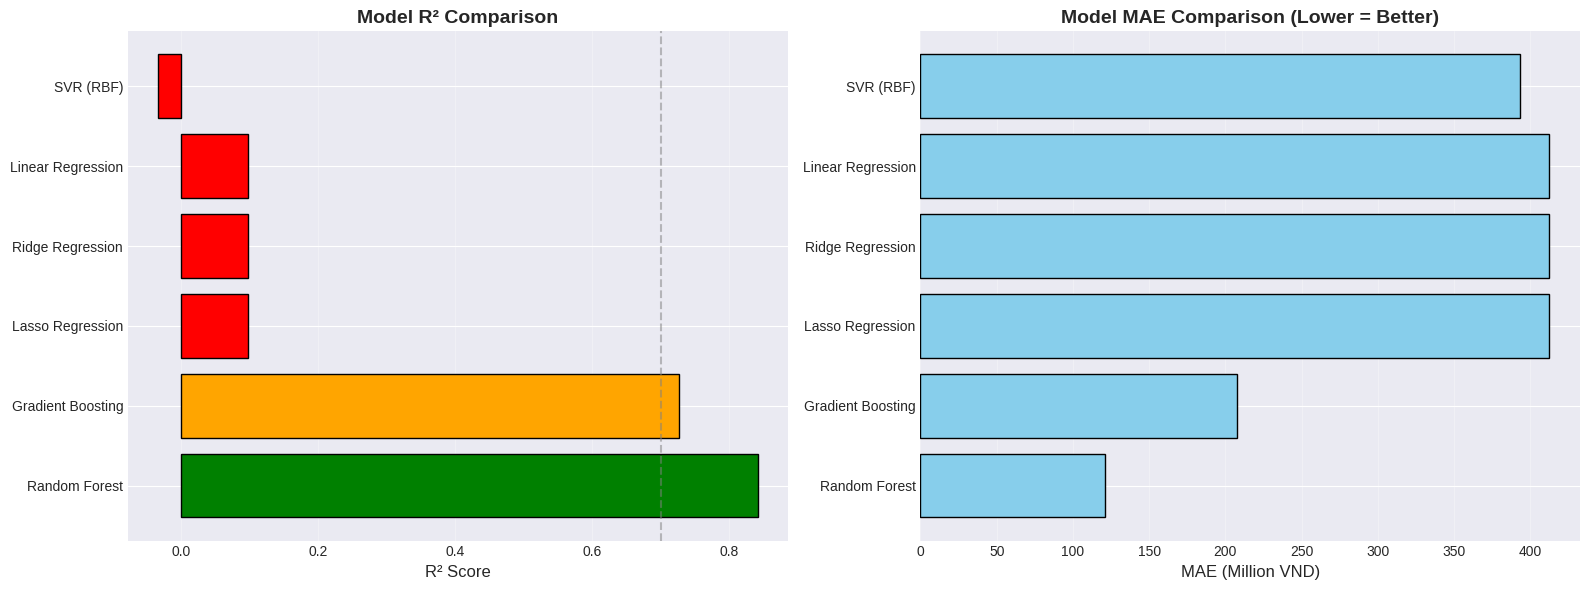

In [42]:
# Visualization: Model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparison
colors = ['green' if r > 0.8 else 'orange' if r > 0.5 else 'red'
          for r in results['R² (Test)']]
axes[0].barh(results['Model'], results['R² (Test)'], color=colors, edgecolor='black')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Model R² Comparison', fontsize=14, weight='bold')
axes[0].axvline(0.7, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(axis='x', alpha=0.3)

# MAE comparison
axes[1].barh(results['Model'], results['MAE (M VND)'], color='skyblue', edgecolor='black')
axes[1].set_xlabel('MAE (Million VND)', fontsize=12)
axes[1].set_title('Model MAE Comparison (Lower = Better)', fontsize=14, weight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Bước 13: Feature Importance - Yếu tố nào làm nên giá xe? 📊
Giúp chúng ta biết được trong mắt AI, năm sản xuất hay hãng xe mới là yếu tố quyết định sự chênh lệch giá. Giá trị phần trăm (%) cho thấy mức độ đóng góp của từng tính năng.


🎯 Feature Importance (Random Forest):
      Feature  Importance
Model_Encoded    0.422511
Brand_Encoded    0.293763
  KM_Negative    0.143413
          Age    0.071149
         Year    0.069165


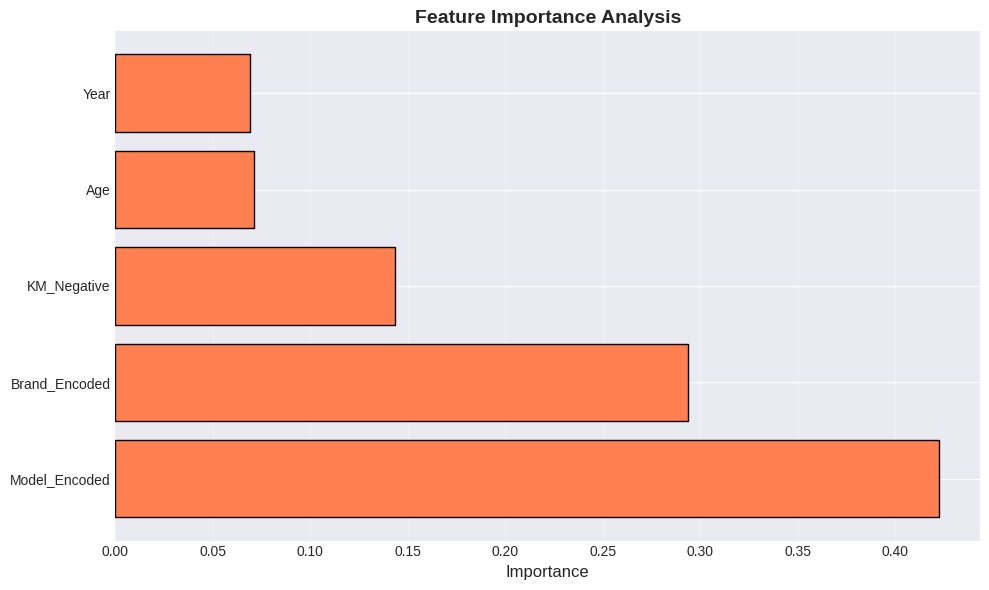


💡 Key Insights:
  - Model_Encoded (dòng xe) chiếm 42.3%
  - Brand_Encoded (hãng xe) chiếm 29.4%
  - Brand + Model = 71.6% importance!


In [43]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🎯 Feature Importance (Random Forest):")
print(feature_importance.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='coral', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance Analysis', fontsize=14, weight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print(f"  - Model_Encoded (dòng xe) chiếm {feature_importance.iloc[0]['Importance']*100:.1f}%")
print(f"  - Brand_Encoded (hãng xe) chiếm {feature_importance.iloc[1]['Importance']*100:.1f}%")
print(f"  - Brand + Model = {(feature_importance.iloc[0]['Importance'] + feature_importance.iloc[1]['Importance'])*100:.1f}% importance!")

In [44]:
# Example 1: Toyota Vios 2020, 50K KM
test_toyota = pd.DataFrame([{
    'Year': 2020,
    'Age': 2026 - 2020,
    'KM_Negative': -50000,
    'Brand_Encoded': le_brand.transform(['Toyota'])[0],
    'Model_Encoded': le_model.transform(['Vios'])[0]
}])

pred_toyota = rf.predict(test_toyota)[0]

print("🚗 Test Case 1: Toyota Vios 2020, 50K KM")
print(f"   Predicted Price: {pred_toyota:.0f} triệu VNĐ")

# Example 2: Honda Civic 2018, 80K KM
test_honda = pd.DataFrame([{
    'Year': 2018,
    'Age': 2026 - 2018,
    'KM_Negative': -80000,
    'Brand_Encoded': le_brand.transform(['Honda'])[0],
    'Model_Encoded': le_model.transform(['Civic'])[0]
}])

pred_honda = rf.predict(test_honda)[0]

print("\n🚗 Test Case 2: Honda Civic 2018, 80K KM")
print(f"   Predicted Price: {pred_honda:.0f} triệu VNĐ")

🚗 Test Case 1: Toyota Vios 2020, 50K KM
   Predicted Price: 406 triệu VNĐ

🚗 Test Case 2: Honda Civic 2018, 80K KM
   Predicted Price: 501 triệu VNĐ
